<a href="https://colab.research.google.com/github/Ajayghulghule/task3/blob/main/task3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = pd.read_csv("car data.csv")

In [3]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [4]:
df.shape

(301, 9)

In [5]:
df.columns

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Driven_kms',
       'Fuel_Type', 'Selling_type', 'Transmission', 'Owner'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [8]:
df.isnull().sum()

,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Driven_kms,0
Fuel_Type,0
Selling_type,0
Transmission,0
Owner,0


In [9]:
df.duplicated().sum()

np.int64(2)

In [10]:
df = df.drop_duplicates()

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df["Car_Age"] = 2026 - df["Year"]

In [14]:
df[["Year", "Car_Age"]].head()

,Year,Car_Age
0,2014,12
1,2013,13
2,2017,9
3,2011,15
4,2014,12


In [15]:
df = df.drop("Car_Name", axis=1)

In [16]:
df.head()

,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age
0,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,12
1,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,13
2,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,9
3,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,15
4,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,12


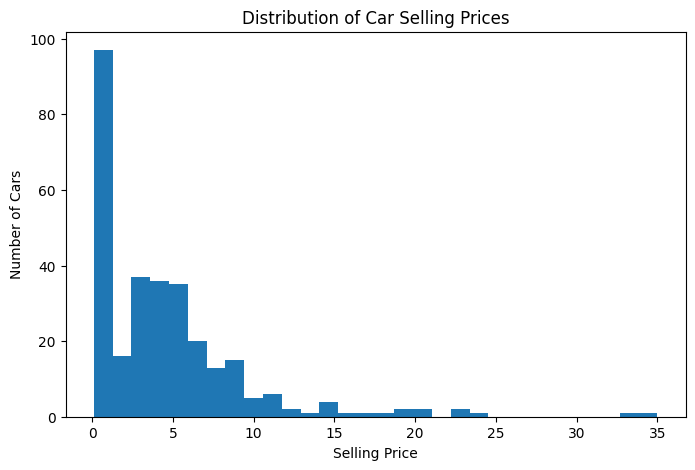

In [17]:
plt.figure(figsize=(8,5))

plt.hist(df["Selling_Price"], bins=30)

plt.xlabel("Selling Price")
plt.ylabel("Number of Cars")
plt.title("Distribution of Car Selling Prices")

plt.show()

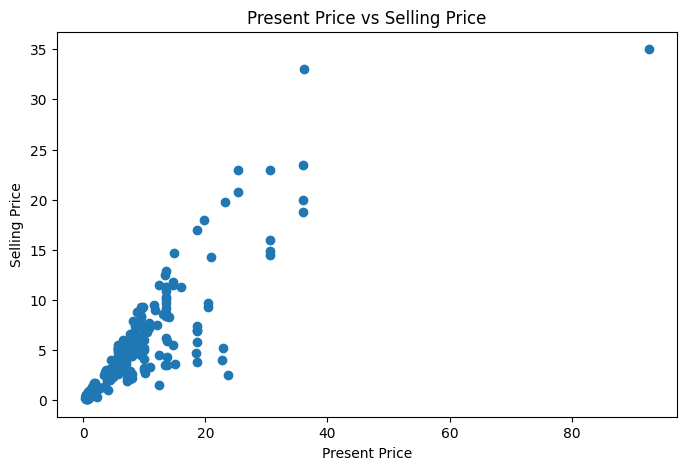

In [18]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["Present_Price"],
    df["Selling_Price"]
)

plt.xlabel("Present Price")
plt.ylabel("Selling Price")
plt.title("Present Price vs Selling Price")

plt.show()

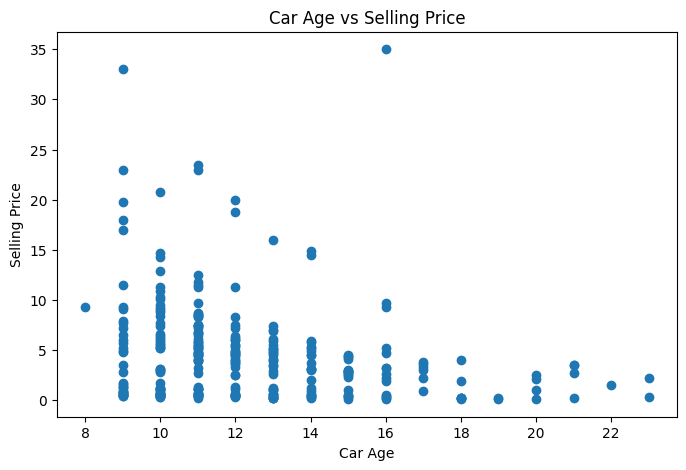

In [19]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["Car_Age"],
    df["Selling_Price"]
)

plt.xlabel("Car Age")
plt.ylabel("Selling Price")
plt.title("Car Age vs Selling Price")

plt.show()

In [20]:
X = df.drop("Selling_Price", axis=1)

y = df["Selling_Price"]

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [22]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (239, 8)
Testing data: (60, 8)


In [23]:
categorical_features = [
    "Fuel_Type",
    "Selling_type",
    "Transmission"
]

In [24]:
numerical_features = [
    "Year",
    "Present_Price",
    "Driven_kms",
    "Owner",
    "Car_Age"
]

In [25]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)

In [26]:
model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "regressor",
            RandomForestRegressor(
                n_estimators=300,
                random_state=42
            )
        )
    ]
)

In [27]:
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Fuel_Type', 'Selling_type',
                                                   'Transmission'])])),
                ('regressor',
                 RandomForestRegressor(n_estimators=300, random_state=42))])

In [28]:
y_pred = model.predict(X_test)

In [29]:
print(y_pred[:10])

[ 9.39393333  8.22583333  0.43966667  6.9165     18.3775      5.30733333
  6.79266667  1.18566667  7.83716667  0.33073333]


In [30]:
comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

comparison.head(10)

,Actual Price,Predicted Price
0,8.99,9.393933
1,8.35,8.225833
2,0.45,0.439667
3,7.45,6.916500
4,5.25,18.377500
5,5.25,5.307333
6,5.85,6.792667
7,1.15,1.185667
8,9.25,7.837167
9,0.38,0.330733


In [31]:
mae = mean_absolute_error(y_test, y_pred)

print("MAE:", mae)

MAE: 1.5509605555555532


In [34]:
mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

print("RMSE:", rmse)

RMSE: 3.7556667130040506


In [32]:
r2 = r2_score(y_test, y_pred)

print("R2 Score:", r2)

R2 Score: 0.4527261493888418


In [35]:
print("----- Model Evaluation -----")

print("Mean Absolute Error:", mae)
print("Root Mean Squared Error:", rmse)
print("R2 Score:", r2)

----- Model Evaluation -----
Mean Absolute Error: 1.5509605555555532
Root Mean Squared Error: 3.7556667130040506
R2 Score: 0.4527261493888418


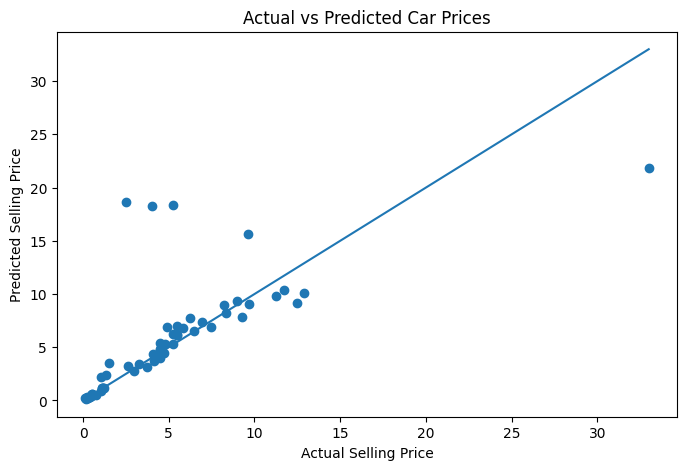

In [36]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual vs Predicted Car Prices")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.show()